Economics output, kWh saved for both winter and summer. hourly outputs for NEM integration

T_indoor_C is a fixed reference indoor temperature.

Transient model based off of finite volume method. 

> **Single-building reference for the Stage 3 engine.**
> The pipeline runs a vectorised port of this model — `stage3_thermal/heat_ingress_model.py`
> (`march_interior_flux` / `annual_benefit` / `run_model`) — for every building in a suburb.
> Keep the two in sync: `tests/test_heat_ingress_model.py` asserts the vectorised march
> reproduces this notebook's transient cell for one building.
>
> This notebook keeps the mock roof (`roof_plan_area`, `roof_tilt`, absorptance `0.8`);
> the pipeline substitutes each building's real Stage 1/2 values
> (`absorptance_before`, `roof_surface_area_m2`, `pitch_deg`).

# **Library Imports**

In [1]:
# dataclass lets us create simple classes without writing lots of setup code
from dataclasses import dataclass

# Path helps Python work with file paths more cleanly than plain strings
from pathlib import Path

# pandas is used to read and inspect CSV tables
import pandas as pd

# numpy gives us np.nan, which represents blank/missing values in tables
# also facilitates numerical operations on arrays, which is useful for our calculations
import numpy as np
import math

# for plotting
import matplotlib.pyplot as pl
# solving initial temps
import scipy.optimize as opt

# Importing input tables
- Table 1: Barra 2 Weather Dataset
- Table 2: Building Parameter Summary
- Table 3: Surface Geometry
- Table 4: Material Properites
- table 5: Roof Layers

In [2]:
# Input tables live in the repo-root "Input Tables/" folder (this notebook sits in
# stage3_thermal/). Probe a few locations so it runs from either the notebook dir
# or the repo root.
#   - material_properties_table4.csv, Regular_Roof.csv  -> committed to the repo
#   - barra2_-37.91_145.13_2007.csv  -> BARRA2 single-point hourly weather extract,
#     regenerated with (no Google Drive / NCI login needed):
#         python -m tools.fetch_heat_ingress_weather --lat -37.91 --lon 145.13 --year 2007
INPUT_DIR = next(
    (p for p in (Path("Input Tables"),
                 Path("../Input Tables"),
                 Path("../../Input Tables"))
     if p.exists()),
    Path("Input Tables"),
)

SHOW_TROUBLESHOOTING = True  # change this to 'False' if tables importing correctly 

# This function loads any input CSV table using the same process, so we don't have to repeat 
# the path checks, CSV import, and blank-cell cleanup for Tables 1-4
def load_input_table(file_name):
    csv_path = INPUT_DIR / file_name

    # ----------------------------- TROUBLESHOOTING -----------------------------
    if SHOW_TROUBLESHOOTING:
        print(f"\nLoading {file_name}")
        print("Python is looking for:")
        print(csv_path.resolve())
        print("File exists?")
        print(csv_path.exists())
    # ---------------------------------------------------------------------------
    # Read the CSV into a pandas DataFrame
    df = pd.read_csv(csv_path)
    # Strip whitespace from column names (removes leading/trailing spaces)
    df.columns = df.columns.str.strip()
    # Turn blank cells into proper missing values so Python can handle them safely
    df = df.replace({"": np.nan})

    return df # Send the cleaned table back to the line that called this function

In [3]:
# ----------------------- TABLE 1: BARRA2 weather data ---------------------------
weather_table = load_input_table("barra2_-37.91_145.13_2007.csv")

# Convert UTC timestamp column into datetime format
weather_table["time_UTC"] = pd.to_datetime(weather_table["time_UTC"], utc=True)

# Convert UTC time to local Melbourne 24hr time and add to end of table
weather_table["time_Melbourne"] = weather_table["time_UTC"].dt.tz_convert("Australia/Melbourne").dt.tz_localize(None)

   #SUMMER
# Filter weather data for Jan-Feb 2007, then omit the first z = 11 filtered rows (9pm 1st Jan)
Z = 0 # z= 0 : 11am jan 1st
summer_weather_table = weather_table[weather_table["time_Melbourne"].dt.month.isin([1,2])].copy().iloc[Z:]
#print("Full year rows:",len(weather_table))
print("Jan-Feb, starting from 4am 2nd jan",len(summer_weather_table))
display(summer_weather_table.head())


'''
# Filter weather data for July 2007
Z = 11 # z= 0 :
summer_weather_table = weather_table[weather_table["time_Melbourne"].dt.month.isin([7])].copy().iloc[Z:]
#print("Full year rows:",len(weather_table))
print("july ",len(summer_weather_table))
display(summer_weather_table.head())
'''

# ----------------------- TABLE 2: Building summary ----------------------------
# buildings_table = load_input_table("buildings.csv")

# ----------------------- TABLE 3: Surface geometry ----------------------------
# surfaces_table = load_input_table("surfaces.csv")

# ----------------------- TABLE 4: Material properties -------------------------
materials_table = load_input_table("material_properties_table4.csv")

# ----------------------- TABLE 5: Roof Layer properties -----------------------
roof_layers_table = load_input_table("Regular_Roof.csv")
display(roof_layers_table.head())


Loading barra2_-37.91_145.13_2007.csv
Python is looking for:
C:\Users\swagk\OneDrive\Desktop\Raising-Rooves-Model-1\Input Tables\barra2_-37.91_145.13_2007.csv
File exists?
True


Jan-Feb, starting from 4am 2nd jan 1416


,time_UTC,rsdsdir_Wm2,rsdsdif_Wm2,temp_K,rel_humidity_percent,wind_ms,rsds_total_Wm2,temp_C,time_Melbourne
0,2007-01-01 00:00:00+00:00,232.542969,395.128906,296.578125,69.400391,2.480469,627.671875,23.428125,2007-01-01 11:00:00
1,2007-01-01 01:00:00+00:00,497.234375,414.375000,298.406250,49.439453,2.533203,911.609375,25.256250,2007-01-01 12:00:00
2,2007-01-01 02:00:00+00:00,434.121094,384.253906,298.640625,46.536072,2.013672,818.375000,25.490625,2007-01-01 13:00:00
3,2007-01-01 03:00:00+00:00,174.375000,440.062500,298.046875,50.794373,3.593750,614.437500,24.896875,2007-01-01 14:00:00
4,2007-01-01 04:00:00+00:00,556.832031,256.214844,298.375000,51.453186,4.273438,813.046875,25.225000,2007-01-01 15:00:00



Loading material_properties_table4.csv
Python is looking for:
C:\Users\swagk\OneDrive\Desktop\Raising-Rooves-Model-1\Input Tables\material_properties_table4.csv
File exists?
True

Loading Regular_Roof.csv
Python is looking for:
C:\Users\swagk\OneDrive\Desktop\Raising-Rooves-Model-1\Input Tables\Regular_Roof.csv
File exists?
True


,Material_type,Thickness_m,Density_Kg_m3,Spec_Heat_Cap_J_KgK,R_value_m2K_W
0,Steel,0.00042,7800.000,480,0.000008
1,Insulation,0.16400,12.000,840,4.100000
2,Cavity,0.30000,1.225,1000,0.333000
3,Plaster,0.01300,950.000,840,0.081250


note: weather data will be read directlty from 'weather_table'. Too compuational demanding to store every row
# Material Class - ultimately to delete 

This section converts Table 4 into Python material objects

Each row in **material_properties_table4.csv** becomes one **Material**

This helps because later the heat-transfer functions can use **material.R_value_m2K_W** instead of repeatedly searching through the CSV table


In [4]:
@dataclass
class Material:
    # Basic identifiers from Table 4
    material_id: str
    archetype: str
    surface_type: str
    scenario: str
    # Thermal properties from Table 4
    U_value_W_m2K: float = None
    solar_reflectance: float = None
    thermal_emittance: float = None
    SHGC: float = None
    # Notes for traceability so assumptions can be checked later
    source: str = None
    notes: str = None

    @property    # i thinkw e can find more accurate solar absorptance values in the literature, based on material and colour 
    def solar_absorptance(self):
        # Solar absorptance is derived, not stored in the CSV
        # For opaque surfaces: absorptance = 1-reflectance
        if self.solar_reflectance is None:
            return None
        return 1.0-self.solar_reflectance
    
# This function converts one row from materials_table into one Material object
def make_material_from_row(row):
    return Material(
        material_id=row["material_id"],
        archetype=row["archetype"],
        surface_type=row["surface_type"],
        scenario=row["scenario"],
        U_value_W_m2K=row["U_value_W_m2K"],
        solar_reflectance=row["solar_reflectance"],
        thermal_emittance=row["thermal_emittance"],
        SHGC=row["SHGC"],
        source=row["source"],
        notes=row["notes"],
    )

# This converts every row in Table 4 into a Material object
materials_table = {row["material_id"]: make_material_from_row(row)for _, row in materials_table.iterrows()}


In [5]:
@dataclass
class Roof_Layers:
    # Basic identifier from Table 5
    Material_type: str
    # Thermal properties from Table 5
    Thickness_m: float = None
    Density_Kg_m3: float = None
    Heat_capacity_J_KgK: float = None
    R_value_m2K_W: float = None

# This function converts one row from Roof_Layers into one roof object
def make_roof_from_row(row):
    return Roof_Layers(
        Material_type=row["Material_type"],
        Thickness_m=row["Thickness_m"],
        Density_Kg_m3=row["Density_Kg_m3"],
        Heat_capacity_J_KgK=row["Spec_Heat_Cap_J_KgK"],
        R_value_m2K_W=row["R_value_m2K_W"],
    )

# This converts every row in Table 5 into a Roof_Layers object
roof_layers_table = {row["Material_type"]: make_roof_from_row(row)for _, row in roof_layers_table.iterrows()}

# testing bottom row to see if info has been pulled correctly 
roof_layers_table["Plaster"]

Roof_Layers(Material_type='Plaster', Thickness_m=0.013, Density_Kg_m3=950.0, Heat_capacity_J_KgK=840, R_value_m2K_W=0.08125)

# Heat Transfer Pathways - roof only
Positive values mean heat is entering the building
for economic analysis - cooling load reduction - is only as a result of the heat transfer through the roof 

Current assumptions:
- Indoor temperature is fixed

Future improvements: 
- Humidity! 

In [6]:
# defining indoor boundary temperature condition 
T_indoor_C = 20 # = initial temp in stuarts code

# DEFINING PARAMETERS - LATER TO BE REPLACED BY INPUT TABLES
# Dummy roof parameters until data is available
roof_plan_area = 120 # the birdseye roof area (plan area) {m^2} 
roof_tilt = 30  # roof pitch (degrees)
roof_azimuth = 0  # direction roof faces
# Azimuth convention
"""0° = North
90° = East
180° = South
270° = West"""

# Assumption: simple roof split into two equal roof planes
roof_planes = pd.DataFrame({
    "roof_plane_id": ["roof_plane_1","roof_plane_2"],
    # Bird's-eye/projected area for each half of the roof
    "plan_area": [roof_plan_area/2,roof_plan_area/2],
    # Roof pitch for each plane
    "tilt_deg": [roof_tilt,roof_tilt],
    # Direction each plane faces
    "azimuth_deg":[roof_azimuth,(roof_azimuth+180)%360],})

# Convert bird's-eye area into actual sloped roof surface area
roof_planes["actual_area"] = (roof_planes["plan_area"]/np.cos(np.radians(roof_planes["tilt_deg"])))
display(roof_planes)

# defining variable for the total actual roof area
actual_roof_area = roof_planes["actual_area"].sum()
display(actual_roof_area)

,roof_plane_id,plan_area,tilt_deg,azimuth_deg,actual_area
0,roof_plane_1,60.0,30,0,69.282032
1,roof_plane_2,60.0,30,180,69.282032


138.56406460551017

# **Shortwave Radiation**

Note: Treating rsdsdir with solar incidence already included, thus dont need an angle factor 


In [7]:
# This function calculates absorbed shortwave radiation at the roof surface
# Outputs the absorbed shortwave radiation in W for the FLAT roof surface

def shortwave_absorbed_roof_W_m2(rsdsdir_Wm2,rsdsdif_Wm2):  

    # Absorbed shortwave radiation for the plan roof area surface
    q_sw_W_m2 = 0.8*(rsdsdir_Wm2+rsdsdif_Wm2)   # used solar absorptance of 0.8 for testing purposes

    return q_sw_W_m2

# ROOF SHORTWAVE
# Copy the Jan-Feb weather table so we can add model outputs without changing the original weather data
roof_sw_table = summer_weather_table.copy()

# Store the roof areas in the output table so the calculation is easy to check later
roof_sw_table["actual_roof_area"] = actual_roof_area

# Run the shortwave function for every hourly weather row
roof_sw_table["q_roof_sw_absorbed_W_m2"] = roof_sw_table.apply(lambda row: shortwave_absorbed_roof_W_m2(row["rsdsdir_Wm2"], row["rsdsdif_Wm2"]), axis=1)

# Show the first few hourly results
display(roof_sw_table.head())

,time_UTC,rsdsdir_Wm2,rsdsdif_Wm2,temp_K,rel_humidity_percent,wind_ms,rsds_total_Wm2,temp_C,time_Melbourne,actual_roof_area,q_roof_sw_absorbed_W_m2
0,2007-01-01 00:00:00+00:00,232.542969,395.128906,296.578125,69.400391,2.480469,627.671875,23.428125,2007-01-01 11:00:00,138.564065,502.1375
1,2007-01-01 01:00:00+00:00,497.234375,414.375000,298.406250,49.439453,2.533203,911.609375,25.256250,2007-01-01 12:00:00,138.564065,729.2875
2,2007-01-01 02:00:00+00:00,434.121094,384.253906,298.640625,46.536072,2.013672,818.375000,25.490625,2007-01-01 13:00:00,138.564065,654.7000
3,2007-01-01 03:00:00+00:00,174.375000,440.062500,298.046875,50.794373,3.593750,614.437500,24.896875,2007-01-01 14:00:00,138.564065,491.5500
4,2007-01-01 04:00:00+00:00,556.832031,256.214844,298.375000,51.453186,4.273438,813.046875,25.225000,2007-01-01 15:00:00,138.564065,650.4375


# External Convection Coefficient Calculation

Local windspeed calcuation - Converts BARRA2 wind speed from the meteorological measurement height to the local wind speed at the roof height. Utilises EnergyPlus Eq. 3.84

External convection coefficient calculation. Utilises EnergyPlus Eq. 3.104 McAdams Eq. Accounting to natural & forced convection


In [8]:
#LOCAL WINDSPEED CALCULATION 
# Defining Roof height above ground - Later this should come from Table 2
z_roof_m = 6
# Site terrain values:  Current assumption: towns/cities
alpha = 0.33
delta = 460
# Meteorological station values:
z_met_m = 10 # assump = EnergyPlus default wind measurement height is 10 m
alpha_met = 0.14 # assump = open country 
delta_met = 270 # assump = open country 

# Calculate local wind speed at roof height and append to shortwave table
roof_sw_table["V_z_ms"] = roof_sw_table["wind_ms"]*(delta_met/z_met_m)**alpha_met*(z_roof_m/delta)**alpha

# External convection coefficient calculation and append to shortwave table
roof_sw_table["h_ext_Wm2K"] = 5.7+3.8*roof_sw_table["V_z_ms"]
display(roof_sw_table[["time_Melbourne","wind_ms","V_z_ms","h_ext_Wm2K"]].head())

,time_Melbourne,wind_ms,V_z_ms,h_ext_Wm2K
0,2007-01-01 11:00:00,2.480469,0.939733,9.270986
1,2007-01-01 12:00:00,2.533203,0.959712,9.346904
2,2007-01-01 13:00:00,2.013672,0.762886,8.598966
3,2007-01-01 14:00:00,3.593750,1.361503,10.873712
4,2007-01-01 15:00:00,4.273438,1.619005,11.852218


## Calculating intial midpoint temp in internal roof temps

Applied a steady state heat balance between the midpoints of each layer + boundaries
external -> steel = convection + shortwave + longwave (Black Body Radiation - using stephan boltzman eq.)
plaster -> steel = convection 
inner layers = conduction 

TSky = Tair - (10 to 20) kelvin 
assuming Tsky_K = Tair_K - 10 for now

In [9]:
x = 2*math.pi/24   # angular frequency of the diurnal (24 h) cycle, rad/hour
print(x)


0.2617993877991494


In [10]:
# defining resistivity values for each roof layer  
R1 = roof_layers_table["Steel"].R_value_m2K_W
R2 = roof_layers_table["Insulation"].R_value_m2K_W
R3 = roof_layers_table["Cavity"].R_value_m2K_W
R4 = roof_layers_table["Plaster"].R_value_m2K_W

# storing first timestep of roof_sw_table into variables for use in matrix calculations
ho = roof_sw_table["h_ext_Wm2K"].iloc[0]
q_sw = roof_sw_table["q_roof_sw_absorbed_W_m2"].iloc[0]

T_air_K = roof_sw_table["temp_C"].iloc[0]+273.15
T_air_C = T_air_K - 237.15
A1 = 17.625; B1 = 243.04
RH = weather_table["rel_humidity_percent"].iloc[0]
upsilon = math.log(RH/100) + (A1*T_air_C)/(B1+T_air_C)
T_dp_C = (B1*upsilon)/(A1-upsilon)
# local clock hour of the first modelled timestep - argument of the Berdahl-Martin diurnal term
hour_local = roof_sw_table["time_Melbourne"].iloc[0].hour
T_sky_K = T_air_K*(0.711+0.0056*T_dp_C+0.000073*T_dp_C**2+0.0123*math.cos(2*math.pi*hour_local/24))
T_indoor_K = T_indoor_C + 273.15

emissivity = 0.9 # emissivity of the roof surface - later to be replaced by input table
const = 5.6703e-8  # stephan boltzmann {W/m^2K^4}

# --------------------------------------------------------------------------------------------------------------
# need define R_indoorair for two different conditions - stagant air (when tindoor) and moving air (aircon/heater on)
R_indoorair = 0.17 # unsure if thsi is for moving air or stagnant air.
# defining hi depending on direction of heat flow
if T_air_K > T_indoor_K:  # heat flow down
    hi = 1/R4 # covection coefficient depends on the plaster layer
    R3 = 0.23 # ISO 6946 0.3 m layer
    guess = [float(T_air_K+10), float(T_air_K-20), float(T_air_K-30), float(T_indoor_K-10),0] # may need to reveiw the def of guess values
else: # heat flow up 
    hi = 1/R_indoorair # convection coefficient depends on the indoor air resistivity
    R3 = 0.16 # ISO 6946 for 0.3 m layer
    guess = [float(T_air_K), float(T_air_K+20), float(T_air_K+30), float(T_indoor_K+10),0] # may need to reveiw the def of guess values
print("Initial guess:", guess)
print("hi =", hi, "W/m^2K")
print("R3 = ", R3)
# ------------------------------------------------------------------------------------------------------
# hi = 3  # overriding for now 
#print("hi =", hi, "W/m^2K")
print("ho =", ho, "W/m^2K")
print("q_sw =", q_sw, "W/m^2")
print("T_air_K =", T_air_K, "K")
print("T_air_C =", T_air_K - 273.15, "C")
print("T_indoor_K =", T_indoor_K, "K")
print("T_indoor_C =", T_indoor_K - 273.15, "C")

# eqautions dervied from steady state analysis of the roof layers and heat fluxes.
def residuals(x):
    T1, T2, T3, T4, q = x  # temps in kelvin
    #F1 = (T4 - T_indoor_K)/(1/hi + R4/2)
    F1 = hi*(T4 - T_indoor_K) - q # plaster-> indoor
    F2 = ho*(T_air_K - T1) + q_sw + emissivity*const*(T_sky_K**4 - T1**4) - q  # air-> steel 
    F3 = (2*(T1 - T2))/(R1 + R2) - q # steel -> ins
    F4 = (2*(T2 - T3))/(R2 + R3) - q # ins -> cavity
    F5 = (2*(T3 - T4))/(R3 + R4) - q # cavity -> plaster
    return np.array([F1, F2, F3, F4, F5])
sol = opt.root(residuals, guess) # iterative root solver 
print(sol.success)
print(sol.message)

T1_K, T2_K, T3_K, T4_K, q_W_m2 = sol.x
T1_C = T1_K - 273.15
T2_C = T2_K - 273.15
T3_C = T3_K - 273.15
T4_C = T4_K - 273.15
#print(T1_K, T2_K, T3_K, T4_K, q_W_m2)
print("steel temperature =",T1_C,"deg C")
print("insulation temperature =",T2_C,"deg C")
print("cavity temperature =",T3_C,"deg C")
print("plaster temperature =",T4_C,"deg C")
print("heat flux =",q_W_m2,"W/m^2")

Initial guess: [306.578125, 276.578125, 266.578125, 283.15, 0]
hi = 12.307692307692307 W/m^2K
R3 =  0.23
ho = 9.27098570563552 W/m^2K
q_sw = 502.13750000000005 W/m^2
T_air_K = 296.578125 K
T_air_C = 23.428125000000023 C
T_indoor_K = 293.15 K
T_indoor_C = 20.0 C
True
The solution converged.
steel temperature = 77.27758645051739 deg C
insulation temperature = 50.90236656822054 deg C
cavity temperature = 23.04761824859628 deg C
plaster temperature = 21.045357182895827 deg C
heat flux = 12.865934558717901 W/m^2


In [11]:
# dependant on the 
# Working of resistance values of R = 0.1 and 0.17. The inverse of these values yields, h = 1/R
# Heat Flow Up, plaster warmer than room, h = 5.9 W/m2 k
# Heat Flow Down, plaster cool than room, h = 10 W/m2 k

# please note i think ^^ is using a plaster R value of 0.1, ours is 0.08125

print("internal convection ceofficient if heat flow down = ", 1/R4)
print("internal convection ceofficient if heat flow up = ",1/R_indoorair)
print(R4)

internal convection ceofficient if heat flow down =  12.307692307692307
internal convection ceofficient if heat flow up =  5.88235294117647
0.08125


## Transient Heat Ingress Model
Outputting hourly q value transmitted from plaster to indoor

To add:

an adpative hi value. depending on if the ceiling temp is higher or lower than inside temp 

floating indoor temp range in which neitehr cooling or heating is applied


In [12]:
numHours = 10
dt = 40 # seconds 
numTimesteps = int(numHours*3600/dt)

layer_order = ["Steel", "Insulation", "Cavity", "Plaster"]
numLayers = len(layer_order)
layers = [roof_layers_table[layer] for layer in layer_order]
Cp = np.array([layer.Heat_capacity_J_KgK for layer in layers], dtype=float)
Thicknesses = np.array([layer.Thickness_m for layer in layers], dtype=float)
R_values = np.array([R1,R2,R3,R4]) # np.array([layer.R_value_m2K_W for layer in layers], dtype=float)
density = np.array([layer.Density_Kg_m3 for layer in layers], dtype=float)

innerLayerId = numLayers-1
hi = 3.0 # TO CHANGE LATER - this is the convective heat transfer coefficient for the indoor air.
T_inside = (T_indoor_C+273.15)

# ----------- to expand model beyond an hour and store the heat fluxes at each timestep ---------------------------
timesteps_per_hour = int(np.ceil(3600 / dt))
hourly_q_values = np.zeros((numHours, numLayers+1))  # to see the heat fluxes at each layer interface at end of simulation TO DELETE
hourly_heat_energy_Wh_m2 = np.zeros(numHours)
current_hour_energy_Wh_m2 = 0

# ----------------------------------------------------------------------------------------------------------------
# MidTemps = np.array([outterTemps[0],outterTemps[0]-5,insideTemps[0]+2, insideTemps[0]+0.5], dtype=float)
MidTemps = np.array([T1_K, T2_K, T3_K, T4_K], dtype=float)

## Determining Maximum Timestep for Given Time Period
atm, this is 2 months in january - could extend to the entire dataset we are trying to analyse. 
OR we could reevaulate this stability condition monthly? if we wanted to use shorter timesteps for the summer months, as its restitance value of the cavity during upwards heat transfer that is limiting our timestep the most. 


Forward Euler must resolve the fastest layer energy balance. The cavity is limiting because its capacity is small relative to its two conductances

The timestep limit is calculated for every laye & the smallest value is selected as the maximum allowable timestep for the entire simulation

In [13]:
# Using the lowest possible cavity resistance for a conservative stability check.
# This does not change the R_values used by the transient simulation.
R_values_for_stability = R_values.copy()
R_values_for_stability[2] = 0.16  # Cavity resistance for upward winter heat flow
face_conductance = 2 / (R_values_for_stability[:-1] + R_values_for_stability[1:])
inner_boundary_conductance = 1 / (R_values_for_stability[-1] / 2 + 1 / hi)
ho_max = float(roof_sw_table["h_ext_Wm2K"].iloc[:numHours + 1].max())
print("hi =", hi, "W/m^2K")
print(f"ho_max = {ho_max} W/m^2K")
layer_conductance_sum = np.r_[
    ho_max + face_conductance[0],
    face_conductance[:-1] + face_conductance[1:],
    face_conductance[-1] + inner_boundary_conductance,]
dt_limits = (density*Cp*Thicknesses)/layer_conductance_sum
limiting_layer_id = int(np.argmin(dt_limits))
dt_max_positive = dt_limits[limiting_layer_id]
print("Forward Euler timestep limits:")
for layer_name, dt_limit in zip(layer_order, dt_limits):
    print(f"  {layer_name}: {dt_limit:.2f} s")
print(
    f"\nLimiting layer: {layer_order[limiting_layer_id]}"
    f" ({dt_max_positive:.2f} s)")
print(f"Maximum allowable timestep: dt < {dt_max_positive:.2f} s")

hi = 3.0 W/m^2K
ho_max = 12.917890005012897 W/m^2K
Forward Euler timestep limits:
  Steel: 117.30 s
  Insulation: 1726.88 s
  Cavity: 41.95 s
  Plaster: 946.17 s

Limiting layer: Cavity (41.95 s)
Maximum allowable timestep: dt < 41.95 s


## with plotting

dt = 40
numTimesteps = 900
initial midpoint temps (C): [77.27758645 50.90236657 23.04761825 21.04535718]


,time,average_shortwave_W_m2,heat_entering_Wh_m2,H_external
1,2007-01-01 12:00:00,615.71250,5.452703,12.633898
2,2007-01-01 13:00:00,691.99375,7.878285,12.637089
3,2007-01-01 14:00:00,573.12500,8.741544,12.640280
4,2007-01-01 15:00:00,570.99375,8.171975,12.643471
5,2007-01-01 16:00:00,546.17500,7.680649,12.646662
6,2007-01-01 17:00:00,367.01250,7.032027,12.649853
7,2007-01-01 18:00:00,256.45625,5.809147,12.653044
8,2007-01-01 19:00:00,162.61875,4.596629,12.656235
9,2007-01-01 20:00:00,60.95000,3.363399,12.659426
10,2007-01-01 21:00:00,8.73125,2.044841,12.662616


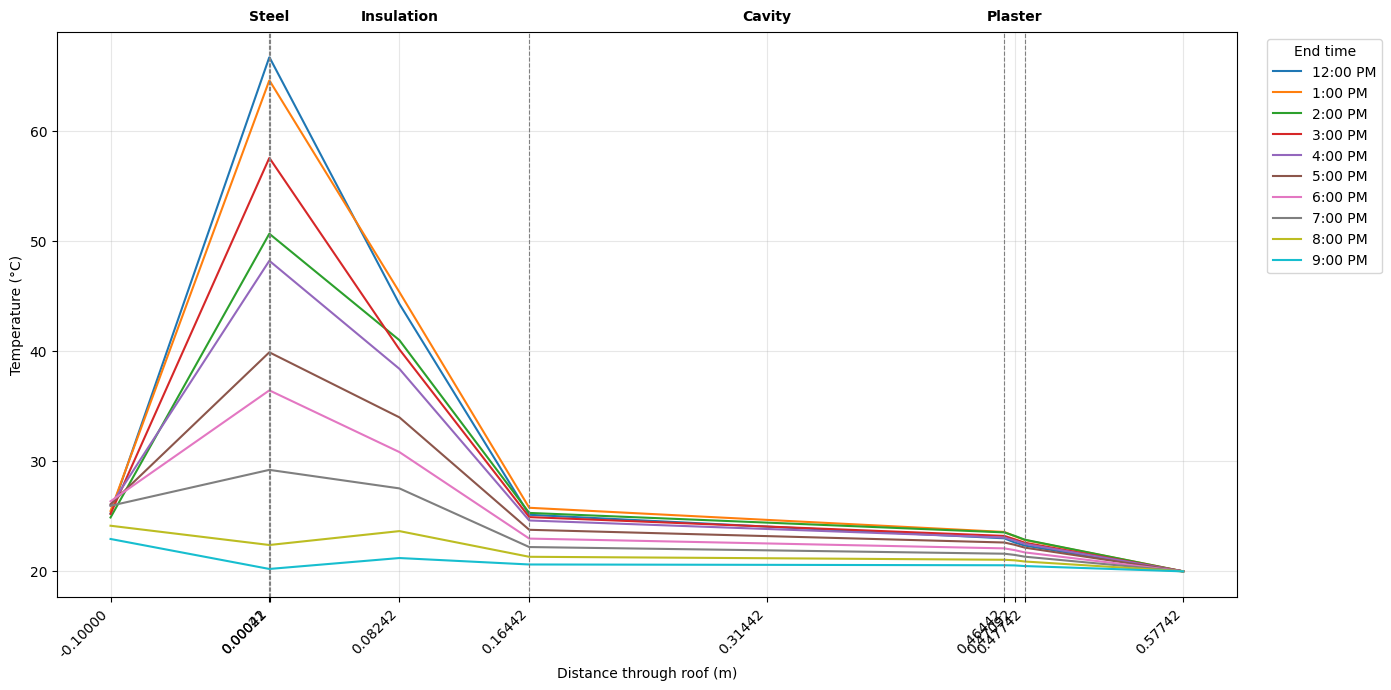

In [14]:
print("dt =", dt)
print("numTimesteps =", numTimesteps)
print("initial midpoint temps (C):", MidTemps - 273.15)

if dt >= dt_max_positive:
    raise ValueError(f"dt={dt} s is too large. Use dt < {dt_max_positive:.2f} s.")

hourly_pathway_C = np.zeros((numHours, 10))
hourly_shortwave_avg_W_m2 = np.zeros(numHours)
x_pathway = np.array([-0.1, Thicknesses[0] / 2, Thicknesses[0], Thicknesses[0] + Thicknesses[1] / 2, Thicknesses[0] + Thicknesses[1], Thicknesses[0] + Thicknesses[1] + Thicknesses[2] / 2, Thicknesses[0] + Thicknesses[1] + Thicknesses[2], Thicknesses[0] + Thicknesses[1] + Thicknesses[2] + Thicknesses[3] / 2, np.sum(Thicknesses), np.sum(Thicknesses) + 0.1])

for hour in range(numHours):
    current_hour_energy_Wh_m2 = 0
    outsideTemps = np.linspace(roof_sw_table["temp_C"].iloc[hour] + 273.15, roof_sw_table["temp_C"].iloc[hour + 1] + 273.15, timesteps_per_hour)
    shortwave = np.linspace(roof_sw_table["q_roof_sw_absorbed_W_m2"].iloc[hour], roof_sw_table["q_roof_sw_absorbed_W_m2"].iloc[hour + 1], timesteps_per_hour)
    ho = np.linspace(roof_sw_table["h_ext_Wm2K"].iloc[hour], roof_sw_table["h_ext_Wm2K"].iloc[hour + 1], timesteps_per_hour)
    hourly_shortwave_avg_W_m2[hour] = np.mean(shortwave)

    for timestep in range(timesteps_per_hour):
        q = np.zeros(numLayers + 1)
        q[0] = shortwave[timestep] + ho[timestep] * (outsideTemps[timestep] - MidTemps[0]) + emissivity * const * ((outsideTemps[timestep] - 10) ** 4 - MidTemps[0] ** 4)

        for j in range(1, numLayers):
            q[j] = 2 * (MidTemps[j - 1] - MidTemps[j]) / (R_values[j - 1] + R_values[j])

        q[-1] = (MidTemps[-1] - T_inside) / (R_values[-1] / 2 + 1 / hi)
        current_hour_energy_Wh_m2 += q[-1] * dt / 3600

        if not np.all(np.isfinite(q)):
            raise ValueError(f"Invalid heat flux at hour={hour}, timestep={timestep}")

        MidTemps += dt * (q[:-1] - q[1:]) / (density * Cp * Thicknesses)

    q_profile = np.zeros(numLayers + 1)
    q_profile[1:-1] = 2 * (MidTemps[:-1] - MidTemps[1:]) / (R_values[:-1] + R_values[1:])
    q_profile[-1] = (MidTemps[-1] - T_inside) / (R_values[-1] / 2 + 1 / hi)
    T_interfaces = MidTemps[:-1] - q_profile[1:-1] * R_values[:-1] / 2
    T_inside_surface = MidTemps[-1] - q_profile[-1] * R_values[-1] / 2

    hourly_pathway_C[hour] = np.r_[outsideTemps[-1], MidTemps[0], T_interfaces[0], MidTemps[1], T_interfaces[1], MidTemps[2], T_interfaces[2], MidTemps[3], T_inside_surface, T_inside] - 273.15
    hourly_q_values[hour] = q
    hourly_heat_energy_Wh_m2[hour] = current_hour_energy_Wh_m2

plot_hours = min(12, numHours)
plot_times = pd.to_datetime(roof_sw_table["time_Melbourne"].iloc[1:plot_hours + 1])
hourly_table = pd.DataFrame({"time": plot_times, "average_shortwave_W_m2": hourly_shortwave_avg_W_m2[:plot_hours], "heat_entering_Wh_m2": hourly_heat_energy_Wh_m2[:plot_hours], "H_external":ho[:plot_hours]})
display(hourly_table)

pathway_labels = ["Outside air", "Steel mid", "Steel/Ins", "Ins mid", "Ins/Cav", "Cav mid", "Cav/Pl", "Plaster mid", "Inside surface", "Inside air"]
layer_boundaries = np.r_[0, np.cumsum(Thicknesses)]

fig, ax = pl.subplots(figsize=(14, 7))

for hour in range(plot_hours):
    ax.plot(x_pathway, hourly_pathway_C[hour], linewidth=1.5, label=plot_times.iloc[hour].strftime("%I:%M %p").lstrip("0"))

for boundary in layer_boundaries:
    ax.axvline(boundary, color="grey", linestyle="--", linewidth=0.8)

for i, layer_name in enumerate(layer_order):
    ax.text((layer_boundaries[i] + layer_boundaries[i + 1]) / 2, 1.02, layer_name, transform=ax.get_xaxis_transform(), ha="center", fontweight="bold")

ax.set_xticks(x_pathway)
ax.set_xticklabels([f"{x:.5f}" for x in x_pathway], rotation=45, ha="right")
ax.set_xlabel("Distance through roof (m)")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
ax.legend(title="End time", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
pl.show()

## Original - with no plots - just printed temps

In [15]:
print("dt = ", dt)
print("numTimesteps = ", numTimesteps)
print("initial midpoint temps (C):", MidTemps - 273.15)

if dt >= dt_max_positive:
    raise ValueError(f"dt={dt} s is too large. Use dt < {dt_max_positive:.2f} s.")

# ---------------------------- TRANSIENT SIMULATION --------------------------------
for hour in range(numHours): # want to loop over each hour to store final q value for NEM integration 
    current_hour_energy_Wh_m2 = 0  # rest the energy accumulator
    # outside temperature boundary conditions, linearised between the start and end of the hour
    outterTemps = np.linspace(roof_sw_table["temp_C"].iloc[hour] + 273.15,roof_sw_table["temp_C"].iloc[hour+1] + 273.15,timesteps_per_hour)
    # shortwave radiation at each timestep
    shortwave = np.linspace(roof_sw_table["q_roof_sw_absorbed_W_m2"].iloc[hour],roof_sw_table["q_roof_sw_absorbed_W_m2"].iloc[hour+1],timesteps_per_hour)
    # external convection coefficient at each timestep
    ho = np.linspace(roof_sw_table["h_ext_Wm2K"].iloc[hour],roof_sw_table["h_ext_Wm2K"].iloc[hour+1],timesteps_per_hour)
        
    for timestep in range(timesteps_per_hour):
        # redfining empy array for heat fluxes at each layer interface, including the outer and inner boundaries
        q = np.zeros(numLayers + 1)
        T_interface = np.zeros(innerLayerId)  # array to store the internal interface temperatures between layers
            
        # outer boundary to steel: shortwave + convective + radiative heat fluxes
        q[0] = (shortwave[timestep] + ho[timestep]*(outterTemps[timestep] - MidTemps[0])+ emissivity*const*((outterTemps[timestep]-20)**4 - MidTemps[0]**4))

        # internal interfaces between layers
        for j in range(1, numLayers):
            q[j] = 2*(MidTemps[j-1]-MidTemps[j]) / (R_values[j-1]+R_values[j])
        
        # calculating the temp for the INTERNAL interface layers. Steel surf and ceiling surf aren't calcluated here
        for i in range(innerLayerId):
            T_interface[i] = MidTemps[i+1] + (q[i+1]*(R_values[i+1]/2)) 
        
        # inner boundary: plaster to indoor air:  
        q[numLayers] = (MidTemps[innerLayerId]-T_inside)/(R_values[innerLayerId]/2 + 1/hi) 
        
        # ideally want to calc Tceiling and then use that to determine hi value 
        T_ceiling = MidTemps[innerLayerId] - (q[numLayers]*(R_values[innerLayerId]/2)) # TO IMPROVE
        ''' 
        # ----------------------------------------------------------------------------------
        if T_ceiling > T_inside:
            hi = 1/R_values[innerLayerId] # covection coefficient depends on the plaster layer
            R_values[2] = 0.23 # ISO 6946 for 0.3 m "unvenitallted air layer"
        else:
            hi = 1/R_indoorair # convection coefficient depends on the indoor air resistivity
            R_values[2] = 0.16 # ISO 6946 for 0.3 m "unvenitallted air layer"
        # ----------------------------------------------------------------------------------
         '''
        # adding the heat flux at the inner boundary to the current hour energy accumulator
        current_hour_energy_Wh_m2 += q[numLayers]*dt/3600
        # Diagnostic check: stop and show where q first becomes invalid.
        if not np.all(np.isfinite(q)):
            print("Invalid q at hour:",hour,"timestep:",timestep)
            print("q =", q)
            print("MidTemps =", MidTemps)
            break

        # Updating the mid layer temperatures using an change in temp. 
        deltaT= np.zeros_like(MidTemps)
        for i in range(numLayers):  # dT = dt*(q enetering - q exiting)/(density*Cp*thickness) derived form heat equation and Fourier's law.
            deltaT[i] = dt*((q[i]-q[i+1]) / (density[i]*Cp[i]*Thicknesses[i]))
           
        MidTemps = MidTemps + deltaT # update the mid layer temps for the next timestep
    #print("R of Cavity = ", R_values[2])
    
    # ----- printing for troubleshooting -------- to delete eventually 
    print(f"hour={hour+1}")
    print(F"interface temps:    {T_interface[0]-273.15:8.3f}     {T_interface[1]-273.15:8.3f}      {T_interface[2]-273.15:8.3f}       {T_ceiling-273.15:8.3f}")
    print(f"Midtemps:    {MidTemps[0]-273.15:8.3f}  {MidTemps[1]-273.15:12.3f}   {MidTemps[2]-273.15:9.3f}   {MidTemps[3]-273.15:11.3f}")
    # net storage > 0  -> layer is gaining heat
    # net storage < 0  -> layer is releasing heat    TO DELETE - just for understanding 
    print("steel storage:", q[0] - q[1], "insulation storage:", q[1] - q[2], "cavity storage:", q[2] - q[3], "plaster storage:", q[3] - q[4], "\n")
    # ---------------------------------------------  
    
    # Store the final heat-flux array from this hour.
    hourly_q_values[hour, :] = q        
    hourly_heat_energy_Wh_m2[hour] = current_hour_energy_Wh_m2 # store the accumulated energy for this hour
# -----------------------------------------------------------------------------
#print("Hourly q values:")
#print(hourly_q_values)
#print(hourly_heat_energy_Wh_m2) 

heat_table =roof_sw_table[["time_Melbourne","temp_C","h_ext_Wm2K","q_roof_sw_absorbed_W_m2"]].iloc[:numHours].copy()
heat_table["heat_entering_Wh_m2"] = hourly_heat_energy_Wh_m2
display(heat_table)

dt =  40
numTimesteps =  900
initial midpoint temps (C): [20.22190198 21.21207802 20.59366663 20.54165259]
hour=1
interface temps:      63.735       23.188        21.539         21.115
Midtemps:      63.898        38.224      22.374        21.266
steel storage: 6.391965269079819 insulation storage: 5.233352701413218 cavity storage: 0.2012921144246409 plaster storage: 3.725102990075159 

hour=2
interface temps:      61.781       24.767        22.746         22.131
Midtemps:      61.752        42.877      23.761        22.400
steel storage: -1.1553991130213905 insulation storage: 0.396502466401067 cavity storage: 0.0850477099707625 plaster storage: 2.351810725548183 

hour=3
interface temps:      48.211       24.699        23.058         22.466
Midtemps:      48.069        39.214      23.876        22.766
steel storage: -5.576383778437751 insulation storage: -2.756985464114493 cavity storage: -0.04766346291649892 plaster storage: -0.2374475292600442 

hour=4
interface temps:      55.060 

,time_Melbourne,temp_C,h_ext_Wm2K,q_roof_sw_absorbed_W_m2,heat_entering_Wh_m2
0,2007-01-01 11:00:00,23.428125,9.270986,502.1375,2.025356
1,2007-01-01 12:00:00,25.256250,9.346904,729.2875,5.005310
2,2007-01-01 13:00:00,25.490625,8.598966,654.7000,7.109151
3,2007-01-01 14:00:00,24.896875,10.873712,491.5500,7.166817
4,2007-01-01 15:00:00,25.225000,11.852218,650.4375,6.960484
5,2007-01-01 16:00:00,25.975000,11.329223,441.9125,6.426334
6,2007-01-01 17:00:00,26.100000,11.481060,292.1125,5.238275
7,2007-01-01 18:00:00,26.365625,10.789358,220.8000,4.026405
8,2007-01-01 19:00:00,25.959375,10.862464,104.4375,2.785527
9,2007-01-01 20:00:00,24.146875,12.633898,17.4625,1.478367
